# Random Forest and Naive Bayes Classifiers

## 📚 Learning Objectives

By completing this notebook, you will:
- Apply random forest classifiers to improve prediction accuracy
- Implement Naive Bayes for text classification tasks
- Evaluate classification models using confusion matrices, ROC curves
- Compare different classification algorithms

## 🔗 Prerequisites

- ✅ Understanding of classification concepts
- ✅ Python 3.8+ installed

---

This notebook covers practical activities from **Course 04, Unit 3**:
- Applying random forest classifiers to improve prediction accuracy
- Implementing Naive Bayes for text classification tasks like spam detection
- Evaluating classification models using confusion matrices, ROC curves

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# CELL: Import the two model families compared in this lesson.
# WHY: Random Forest (an ensemble of trees) and Naive Bayes (a probabilistic
# model) represent opposite philosophies - flexible vs. simple-but-fast.
# CountVectorizer turns raw text into word counts for the spam example.
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## Part 1: Random Forest Classification


In [2]:
# Generate classification dataset
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=1000, n_features=10, n_informative=5,
    n_redundant=2, n_classes=2, random_state=42
)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train a Random Forest classifier (an ensemble of decision trees)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predictions: class labels and probabilities for the positive class
rf_pred = rf.predict(X_test)
rf_pred_proba = rf.predict_proba(X_test)[:, 1]

print("=" * 60)
print("Random Forest Classification:")
print("=" * 60)
print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")
print(f"Test accuracy: {rf.score(X_test, y_test):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Classification:
Training samples: 700, Test samples: 300
Test accuracy: 0.9400

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.94       158
           1       0.94      0.93      0.94       142

    accuracy                           0.94       300
   macro avg       0.94      0.94      0.94       300
weighted avg       0.94      0.94      0.94       300



## Part 2: Naive Bayes for Text Classification (Spam Detection)


In [3]:
# Example: Spam detection with Naive Bayes
# Simulated email data
emails = [
    "Free money click here now",
    "Win a prize claim your reward today",
    "Limited offer buy now cheap discount",
    "Congratulations you won free cash",
    "Meeting scheduled for tomorrow morning",
    "Please review the attached project report",
    "Lunch plans for today at noon",
    "Reminder about the team standup meeting",
]
labels = [1, 1, 1, 1, 0, 0, 0, 0]  # 1 = spam, 0 = ham (not spam)

# Convert text into word-count features
vectorizer = CountVectorizer()
X_text = vectorizer.fit_transform(emails)

# Train a Multinomial Naive Bayes classifier (well suited to word counts)
nb_model = MultinomialNB()
nb_model.fit(X_text, labels)

# Classify new, unseen emails
new_emails = ["Free prize click now", "Team meeting tomorrow at the office"]
new_X = vectorizer.transform(new_emails)
nb_pred = nb_model.predict(new_X)
nb_proba = nb_model.predict_proba(new_X)

print("=" * 60)
print("Naive Bayes Spam Detection:")
print("=" * 60)
for email, pred, proba in zip(new_emails, nb_pred, nb_proba):
    verdict = "SPAM" if pred == 1 else "HAM (not spam)"
    print(f"'{email}' -> {verdict} (spam probability: {proba[1]:.4f})")

Naive Bayes Spam Detection:
'Free prize click now' -> SPAM (spam probability: 0.9746)
'Team meeting tomorrow at the office' -> HAM (not spam) (spam probability: 0.0148)


## Part 3: Evaluation Metrics - Confusion Matrix and ROC Curve


ROC Curve Analysis:
ROC AUC Score: 0.9856
True Positive Rate at FPR=0.2: 1.0000

Confusion Matrix Interpretation:
True Negatives (TN): 150
False Positives (FP): 8
False Negatives (FN): 10
True Positives (TP): 132

Precision: 0.9429
Recall: 0.9296
F1-Score: 0.9362


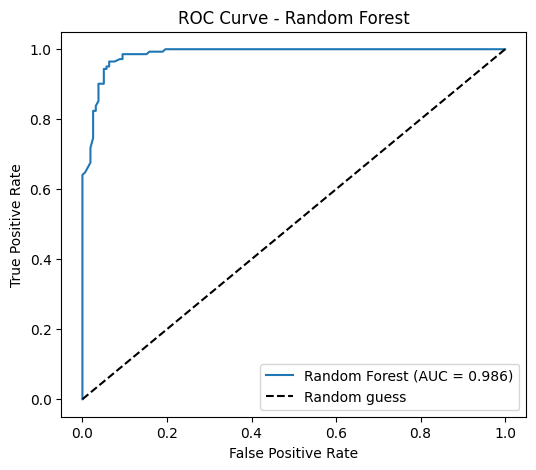

In [4]:
# ROC Curve for Random Forest
fpr, tpr, thresholds = roc_curve(y_test, rf_pred_proba)
roc_auc = auc(fpr, tpr)
print("=" * 60)
print("ROC Curve Analysis:")
print("=" * 60)
print(f"ROC AUC Score: {roc_auc:.4f}")
print(f"True Positive Rate at FPR=0.2: {np.interp(0.2, fpr, tpr):.4f}")

# Confusion matrix interpretation
cm = confusion_matrix(y_test, rf_pred)
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix Interpretation:")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")
print(f"\nPrecision: {tp/(tp+fp):.4f}")
print(f"Recall: {tp/(tp+fn):.4f}")
print(f"F1-Score: {2*tp/(2*tp+fp+fn):.4f}")


# Plot the ROC curve (TPR vs FPR)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

## Summary

### Key Concepts:
1. **Random Forest**: Ensemble of decision trees, reduces overfitting
2. **Naive Bayes**: Probabilistic classifier, excellent for text classification
3. **Confusion Matrix**: Shows TP, TN, FP, FN for detailed evaluation
4. **ROC Curve**: Plots TPR vs FPR, AUC score summarizes performance

### Applications:
- Random Forest: General classification tasks
- Naive Bayes: Spam detection, text classification, document categorization

**Reference:** Course 04, Unit 3: "Applying random forest classifiers" and "Implementing Naive Bayes for text classification"


## 📚 References

1. Breiman, L. (2001). *Random Forests*. Machine Learning, 45, 5–32.
2. Domingos, P., & Pazzani, M. (1997). *On the Optimality of the Simple Bayesian Classifier under Zero-One Loss*. Machine Learning, 29, 103–130.
3. Grinsztajn, L., Oyallon, E., & Varoquaux, G. (2022). *Why Do Tree-Based Models Still Outperform Deep Learning on Tabular Data?* NeurIPS 2022 Datasets and Benchmarks. <https://arxiv.org/abs/2207.08815>
